In [1]:
#importando bibliotecas
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
%matplotlib inline

import requests
from io import BytesIO

In [2]:
#carrega a base de bados
df = pd.read_csv('/Users/claudiojacomassi/Documents/GitHub/Exercicio Aula Aprendizado de Máquina Não Supervisionado 1/vinhos_dataset_cleaned.csv' , index_col=0)

In [3]:
# Certificando que esta usando a df sem duplicadas
df.shape

(5320, 12)

In [4]:
#mostra cabecario e primeiras 5 linhas
df.head()

,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
fixed_acidity,,,,,,,,,,,,
0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152,5,red
0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833,5,red
0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833,5,red
3.019841,-0.381197,1.641293,-0.699699,0.496751,-0.732258,-0.953146,1.168444,-0.403229,0.311515,-0.631833,6,red
0.140064,1.877583,-2.164515,-0.721923,0.496751,-0.956934,-1.305451,1.100996,1.779304,0.177941,-0.969152,5,red


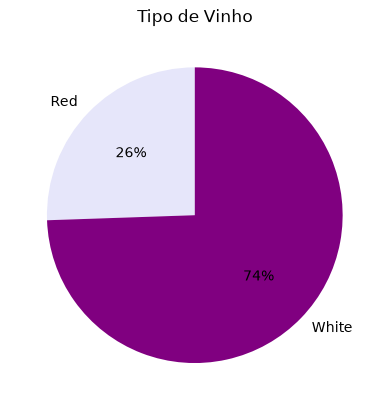

In [5]:
# PLotando em formato pizza a quantidade em % de vinhos red e white
num_red = df[df['color'] == 'red'].shape[0]
num_white = df[df['color'] == 'white'].shape[0]
plt.pie(
    [num_red, num_white],
    labels=['Red', 'White'],
    startangle=90,
    autopct='%1.f%%',
    colors=['lavender', 'purple'])
plt.title('Tipo de Vinho')
plt.show()

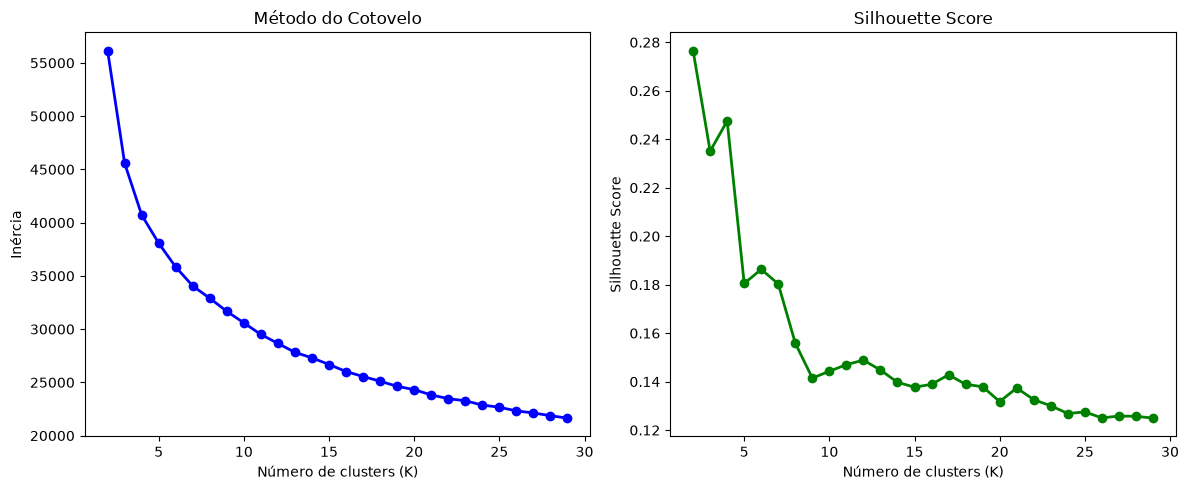

In [6]:
#importando bibliotecas faltantes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Carrega a df novamente (nao entendi porque teve que carregar novamente ?)
df = pd.read_csv(
    "/Users/claudiojacomassi/Documents/GitHub/Exercicio Aula Aprendizado de Máquina Não Supervisionado 1/vinhos_dataset.csv"
)

# Seleciona todos os "features" exceto qualidade e cor
features = [
    'fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X = df[features]

# Faz o scaler dos "features" usando o standardscaler e transforma usando a formula z = X - X_mean / X_std - agora todos os valores estao em escalas parecidas e nao pH entre 1 e 14 e sultatios entre 0 e 1 por examplo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Teste do numero de clusters (nao funcionou com 1 a 30)
ks = range(2, 30)

inercias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # Inercia
    inercias.append(km.inertia_)

    # Silhouette
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Plota os diagnosticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(ks, inercias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')

# Silhouette
ax2.plot(ks, silhouettes, 'go-', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [ ]:
# K-Means com 9 clusters (do grafico de Silhoetes (distancia entre pontos mesmo cluster e distancia de outros clusters) no ponto de inflexao ja que o ponto de inflexao de inercia (distancia entre pontos do mesmo cluster) nao e muito nitido)
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

# Ajusta o modelo e atribui cada vinho a um cluster
df['cluster'] = kmeans.fit_predict(X_scaled)

# contagem de vinhos red e whites de cada cluster
cluster_color = pd.crosstab(
    df['cluster'],
    df['color']
)

print(cluster_color)

color    red  white
cluster            
0        917     89
1          4   1869
2        638     49
3         40   2891


In [ ]:
# Resumo de cada cluster

summary = df.groupby('cluster')[features + ['quality']].agg(
    ['mean', 'std', 'min', 'max']
)

summary

KeyError: 'clusters'